In [1]:
from sklearn.datasets import make_regression
from helpers import *
from filters import *
from functools import partial


In [2]:
import numpy as np
preds = np.load('./preds_mcd_af.npy')
gts = np.load('./gts_mcd_af.npy')

gts_nAF = 1-gts
gts_AF = gts
preds_nAF = preds[:,0]
preds_AF = preds[:,1]

In [3]:
test_preds = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/test_preds/preds_mcd_af.npy')
test_gts = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/test_preds/gts_mcd_af.npy')

In [4]:
test_noise_preds = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/noise_preds/preds_mcd_af.npy')
test_noise_gts = np.load('<path>/checkpoints_af_mcd_sgd_0.001_1e-10_64_0.9_8_0.05/noise_preds/gts_mcd_af.npy')

In [5]:
test_preds_AF = test_preds[:,1]
intervals = []
for i,pred in enumerate(test_preds_AF):
    #print(i/15377)
    intervals.append(predict_interval(pred,preds_AF,gts_AF))

In [6]:
test_noise_preds_AF = test_noise_preds[:,1]
intervals_noise = []
for i,pred in enumerate(test_noise_preds_AF):
    #print(i/15377)
    intervals_noise.append(predict_interval(pred,preds_AF,gts_AF))

# Threshold 0.5

## Retain only

### Original test set

/tmp/ipykernel_3776229/1486353174.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_3776229/1486353174.py:98: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_3776229/1486353174.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_3776229/1486353174.py:101: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.1115
AURC cost-aware rule: 0.1170

AUCC naive rule:      512.4814$
AUCC cost-aware rule: 496.9960$


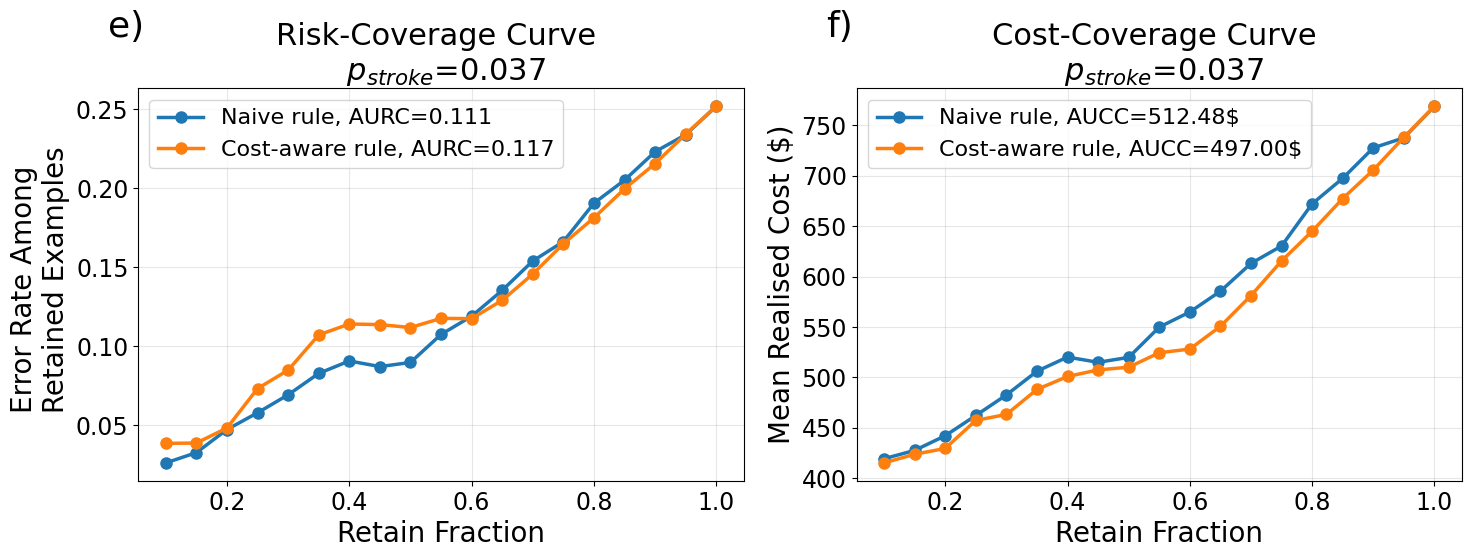

In [7]:
# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.037)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.037,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals),
        y_true=test_gts,
        cost_fn=cost_fn,
        threshold=0.5,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.5).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.037,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}")
print(f"AURC cost-aware rule: {aurc_ec:.4f}")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction", fontsize=20)
axes[0].set_ylabel("Error Rate Among \n Retained Examples", fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.037", fontsize=22)
axes[0].tick_params(axis="both", labelsize=17)
axes[0].legend(fontsize=16)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naive rule, AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware rule, AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction", fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)", fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.037", fontsize=22)
axes[1].tick_params(axis="both", labelsize=17)
axes[1].legend(fontsize=16)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Original Test Set", fontsize=26, y=.9)

axes[0].text(
    -0.05, 1.2, "e)",
    transform=axes[0].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)

axes[1].text(
    -0.05, 1.2, "f)",
    transform=axes[1].transAxes,
    fontsize=26,
    va="top",
    ha="left",
)
# Leave room for suptitle
plt.tight_layout()
#fig.savefig("risk_cost_coverage_original_test_set_55.pdf", format="pdf", bbox_inches="tight")



plt.show()

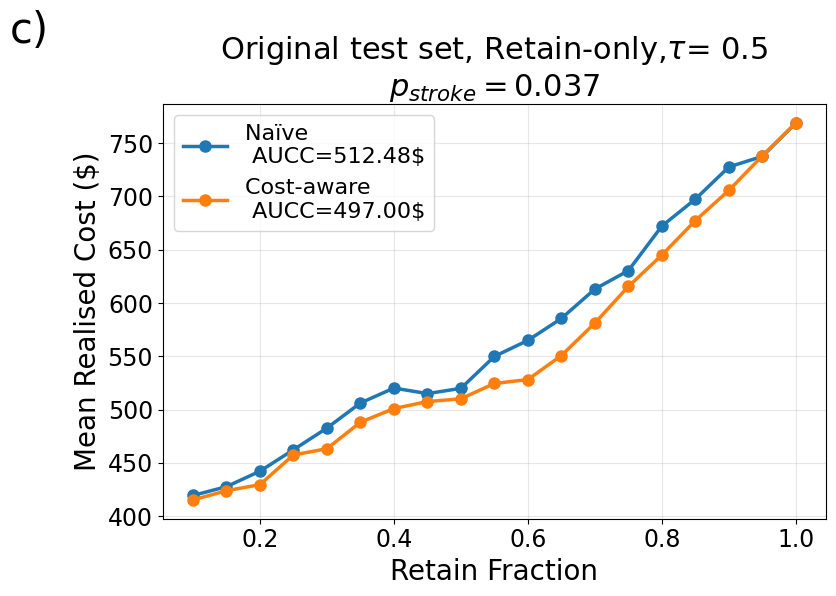

In [8]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title("Original test set, Retain-only," + r'$\tau$' + "= 0.5\n$p_{stroke}=0.037$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "c)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "cost_coverage_original_test_set_37.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

### augmented test set

/tmp/ipykernel_3776229/4033406484.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
/tmp/ipykernel_3776229/4033406484.py:94: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)
/tmp/ipykernel_3776229/4033406484.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
/tmp/ipykernel_3776229/4033406484.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)


AURC naive rule:      0.5462
AURC cost-aware rule: 0.5468

AUCC naive rule:      718.0400$
AUCC cost-aware rule: 717.1152$


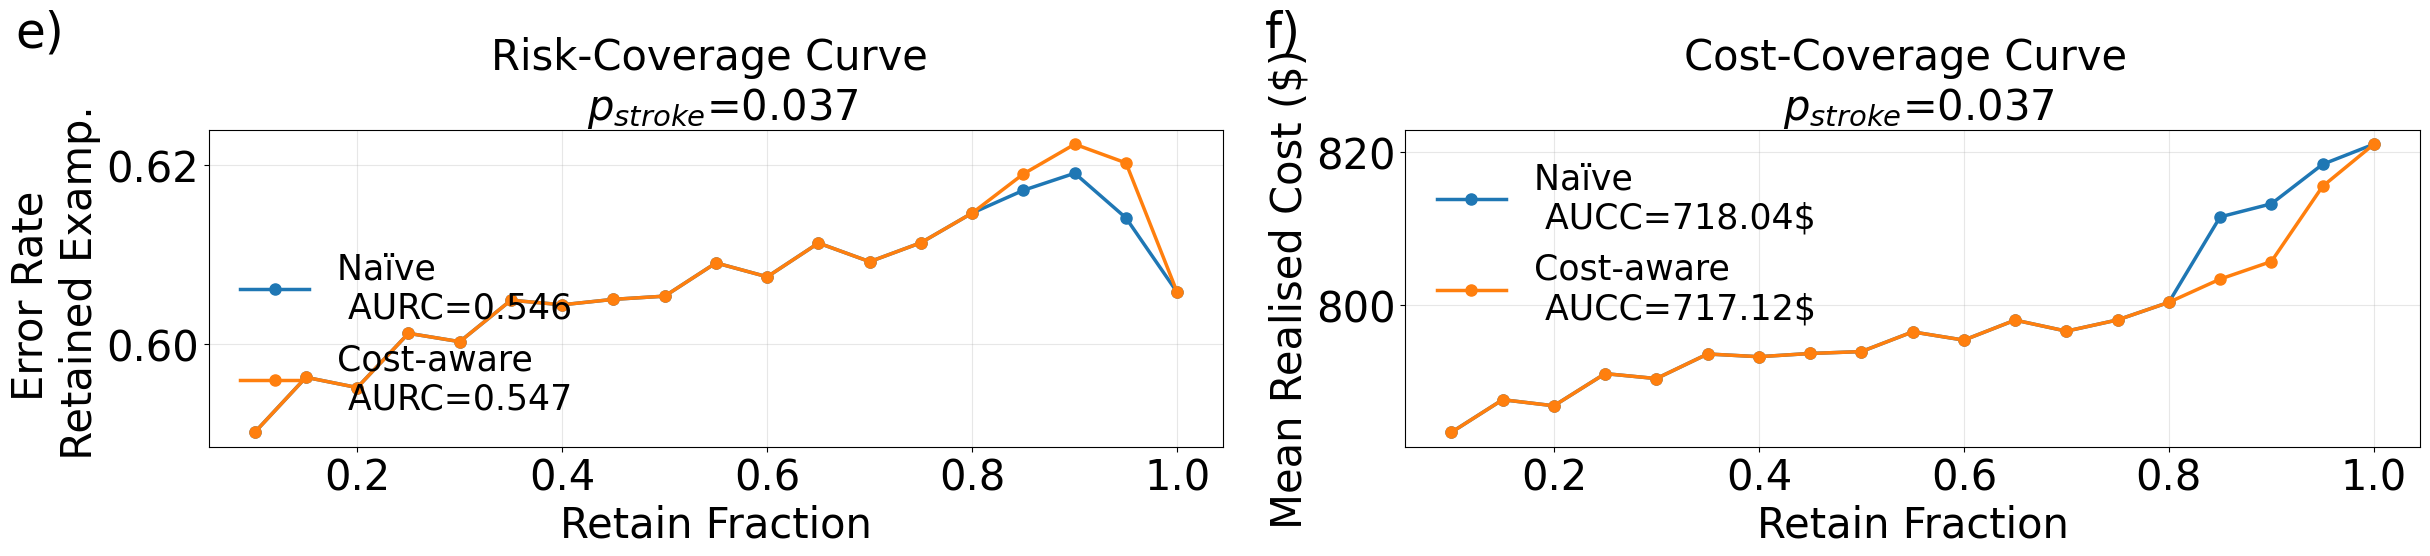

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Risk-coverage / cost-coverage analysis
# ------------------------------------------------------------

retain_fractions = np.linspace(0.1, 1.0, 19)

risks_mag_filtered = []
risks_ec_filtered = []

expected_costs_mag_filtered = []
expected_costs_ec_filtered = []
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.037)

for rf in retain_fractions:

    # --------------------------------------------------------
    # Naive rule: retain by probability magnitude / confidence
    # --------------------------------------------------------
    out_mag_filtered = evaluate_va_prob_magnitude_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        retain_fraction=rf,
        pred_method="collapse",
    )

    remaining_probs_mag = out_mag_filtered["arrays"]["retained_p_hat"]
    remaining_gts_mag = out_mag_filtered["arrays"]["retained_y_true"]

    remaining_preds_mag = (remaining_probs_mag >= 0.5).astype(int)

    risk_mag = np.mean(remaining_preds_mag != remaining_gts_mag)
    risks_mag_filtered.append(risk_mag)

    cost_mag = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_mag,
        remaining_gts_mag,
        p_stroke_missed_af=.037,
    )["expected_cost"]

    expected_costs_mag_filtered.append(cost_mag)

    # --------------------------------------------------------
    # Cost-aware rule: reject by expected decision cost
    # --------------------------------------------------------
    out_ec_filtered = evaluate_va_expected_cost_filtering(
        intervals=np.squeeze(intervals_noise),
        y_true=test_noise_gts,
        cost_fn=cost_fn,
        threshold=0.5,
        reject_fraction=1 - rf,
        pred_method="collapse",
    )

    remaining_probs_ec = out_ec_filtered["arrays"]["retained_p_hat"]
    remaining_gts_ec = out_ec_filtered["arrays"]["retained_y_true"]

    remaining_preds_ec = (remaining_probs_ec >= 0.5).astype(int)

    risk_ec = np.mean(remaining_preds_ec != remaining_gts_ec)
    risks_ec_filtered.append(risk_ec)

    cost_ec = compute_af_screening_cost(
        preds_AF,
        gts_AF,
        remaining_probs_ec,
        remaining_gts_ec,
        p_stroke_missed_af=.037,
    )["expected_cost"]

    expected_costs_ec_filtered.append(cost_ec)


# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------

risks_mag_filtered = np.asarray(risks_mag_filtered)
risks_ec_filtered = np.asarray(risks_ec_filtered)

expected_costs_mag_filtered = np.asarray(expected_costs_mag_filtered)
expected_costs_ec_filtered = np.asarray(expected_costs_ec_filtered)


# ------------------------------------------------------------
# Compute summary metrics
# ------------------------------------------------------------

aurc_mag = np.trapz(risks_mag_filtered, retain_fractions)
aurc_ec = np.trapz(risks_ec_filtered, retain_fractions)

aucc_mag = np.trapz(expected_costs_mag_filtered, retain_fractions)
aucc_ec = np.trapz(expected_costs_ec_filtered, retain_fractions)

print(f"AURC naive rule:      {aurc_mag:.4f}")
print(f"AURC cost-aware rule: {aurc_ec:.4f}")
print()
print(f"AUCC naive rule:      {aucc_mag:.4f}$")
print(f"AUCC cost-aware rule: {aucc_ec:.4f}$")


# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# ------------------------------------------------------------
# Plot risk-coverage and cost-coverage curves
# ------------------------------------------------------------

# Larger global font settings
plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 30,
    "figure.titlesize": 30,
})

fig, axes = plt.subplots(1, 2, figsize=(25, 6))

# Risk-coverage curve
axes[0].plot(
    retain_fractions,
    risks_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AURC={aurc_mag:.3f}",
)

axes[0].plot(
    retain_fractions,
    risks_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AURC={aurc_ec:.3f}",
)

axes[0].set_xlabel("Retain Fraction")#, fontsize=20)
axes[0].set_ylabel("Error Rate \n Retained Examp.")#, fontsize=20)
axes[0].set_title("Risk-Coverage Curve \n $p_{stroke}$=0.037")#, fontsize=22)
axes[0].tick_params(axis="both")#, labelsize=17)
axes[0].legend(fontsize=35)
axes[0].grid(True, alpha=0.3)


# Cost-coverage curve
axes[1].plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

axes[1].plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

axes[1].set_xlabel("Retain Fraction")#, fontsize=20)
axes[1].set_ylabel("Mean Realised Cost ($)")#, fontsize=20)
axes[1].set_title("Cost-Coverage Curve \n $p_{stroke}$=0.037")#, fontsize=22)
axes[1].tick_params(axis="both")#, labelsize=17)
axes[1].legend(fontsize=30)
axes[1].grid(True, alpha=0.3)

# Main title
#fig.suptitle("Augmented Test Set", fontsize=35, y=.9, x=.43)

fig.text(
    0.02, 0.97, "e)",
    #transform=axes[0].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

fig.text(
    0.52, 0.97, "f)",
    #transform=axes[1].transAxes,
    fontsize=35,
    va="top",
    ha="left",
)

axes[0].legend(
    fontsize=25,
    loc="lower left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

axes[1].legend(
    fontsize=25,
    loc="upper left",
    #bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
# Leave room for suptitle
# Leave room for suptitle
plt.tight_layout()
#fig.savefig("./risk_cost_coverage_augmented_test_set_55.pdf", format="pdf", bbox_inches="tight")
plt.show()

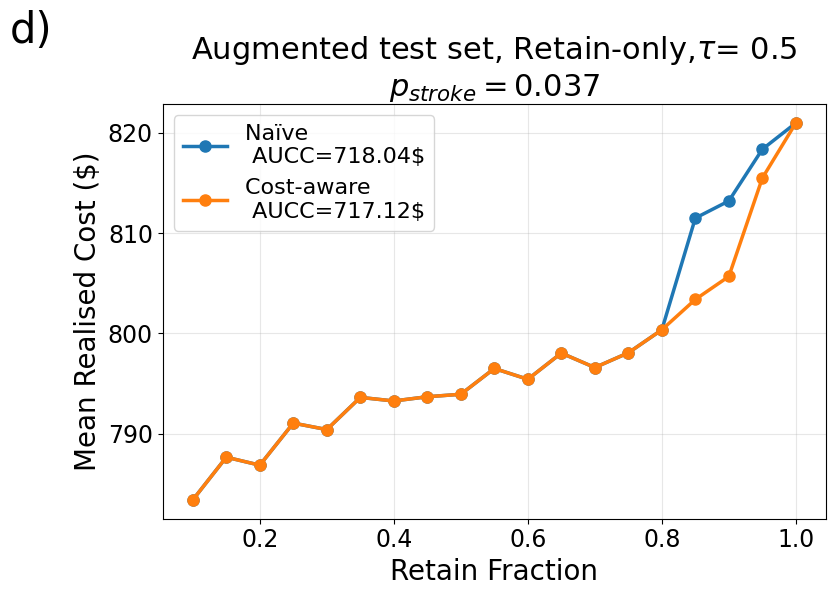

In [10]:
# ------------------------------------------------------------
# Plot cost-coverage curve only
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 15,
    "figure.titlesize": 24,
})

fig, ax = plt.subplots(figsize=(8, 6))

# Cost-coverage curve
ax.plot(
    retain_fractions,
    expected_costs_mag_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Naïve \n AUCC={aucc_mag:.2f}$",
)

ax.plot(
    retain_fractions,
    expected_costs_ec_filtered,
    marker="o",
    markersize=8,
    linewidth=2.5,
    label=f"Cost-aware \n AUCC={aucc_ec:.2f}$",
)

ax.set_xlabel("Retain Fraction", fontsize=20)
ax.set_ylabel("Mean Realised Cost ($)", fontsize=20)
ax.set_title("Augmented test set, Retain-only," + r'$\tau$' + "= 0.5\n$p_{stroke}=0.037$",
    fontsize=22,
)

ax.tick_params(axis="both", labelsize=17)
ax.legend(fontsize=16)
ax.grid(True, alpha=0.3)
fig.text(
    -0.05, 1, "d)",
    #transform=axes[1].transAxes,
    fontsize=30,
    va="top",
    ha="left",
)

plt.tight_layout()

fig.savefig(
    "cost_coverage_augmented_test_set_37.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

## ECE 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss, log_loss


def evaluate_venn_abers_both_classes(
    intervals,
    y_true,
    n_bins=10,
    plot=True,
    ax=None,
):
    """
    Evaluate binary Venn-Abers predictions using collapsed probabilities
    for both classes and optionally draw a reliability diagram.

    Parameters
    ----------
    intervals : array-like of shape (n_samples, 2)
        Rows are [p0, p1], where:
            p0 = VA probability under assumed label 0
            p1 = VA probability under assumed label 1

    y_true : array-like of shape (n_samples,)
        Binary labels in {0,1}

    n_bins : int, default=10
        Number of quantile bins.

    plot : bool, default=True
        Whether to produce a reliability diagram.

    ax : matplotlib axis, optional
        Existing axis.

    Returns
    -------
    dict
    """

    # -----------------------------
    # 1) Input cleaning
    # -----------------------------
    intervals = np.asarray(intervals, dtype=float)
    y_true = np.asarray(y_true, dtype=int).reshape(-1)

    if intervals.ndim != 2 or intervals.shape[1] != 2:
        raise ValueError(
            "intervals must have shape (n_samples, 2)"
        )

    if len(intervals) != len(y_true):
        raise ValueError(
            "intervals and y_true must have same length"
        )

    if not np.all(np.isin(y_true, [0, 1])):
        raise ValueError("y_true must contain only 0/1 labels")

    # -----------------------------
    # 2) Venn-Abers collapse
    # -----------------------------
    p0 = np.minimum(intervals[:, 0], intervals[:, 1])
    p1 = np.maximum(intervals[:, 0], intervals[:, 1])

    width = p1 - p0

    denom = np.maximum(1.0 - p0 + p1, 1e-15)

    p_pos = p1 / denom
    p_pos = np.clip(p_pos, 1e-15, 1 - 1e-15)

    p_neg = 1.0 - p_pos

    # -----------------------------
    # 3) Global summaries
    # -----------------------------
    prevalence_pos = float(np.mean(y_true))
    prevalence_neg = float(1.0 - prevalence_pos)

    sharpness = {
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
        "p90_width": float(np.quantile(width, 0.90)),
        "max_width": float(np.max(width)),
    }

    # -----------------------------
    # 4) Scoring metrics
    # -----------------------------
    brier = float(
        brier_score_loss(y_true, p_pos)
    )

    ll = float(
        log_loss(y_true, p_pos, labels=[0, 1])
    )

    # -----------------------------
    # 5) Reliability bins
    # -----------------------------
    quantiles = np.linspace(0, 1, n_bins + 1)

    edges = np.quantile(p_pos, quantiles)
    edges[0] = -np.inf
    edges[-1] = np.inf

    bin_ids = np.digitize(
        p_pos,
        edges[1:-1],
        right=True
    )

    reliability_rows = []

    ece_pos = 0.0
    ece_neg = 0.0

    for b in range(n_bins):

        idx = np.where(bin_ids == b)[0]

        if len(idx) == 0:
            continue

        yt = y_true[idx]

        emp_pos = float(np.mean(yt))
        emp_neg = float(1.0 - emp_pos)

        avg_p_pos = float(np.mean(p_pos[idx]))
        avg_p_neg = float(np.mean(p_neg[idx]))

        weight = len(idx) / len(y_true)

        ece_pos += weight * abs(
            emp_pos - avg_p_pos
        )

        ece_neg += weight * abs(
            emp_neg - avg_p_neg
        )

        reliability_rows.append(
            {
                "bin": int(b),
                "count": int(len(idx)),
                "empirical_rate_pos": emp_pos,
                "empirical_rate_neg": emp_neg,
                "avg_collapsed_p_pos": avg_p_pos,
                "avg_collapsed_p_neg": avg_p_neg,
            }
        )

    collapsed_metrics = {
        "brier_score": brier,
        "log_loss": ll,
        "ece_pos": float(ece_pos),
        "ece_neg": float(ece_neg),
    }

    # -----------------------------
    # 6) Reliability diagram
    # -----------------------------
    fig = None

    if plot:

        if ax is None:
            fig, ax = plt.subplots(
                figsize=(7, 7)
            )
        else:
            fig = ax.figure

        ax.plot(
            [0, 1],
            [0, 1],
            "--",
            color="gray",
            label="Perfect calibration",
        )

        # Class 1
        x_pos = [
            row["avg_collapsed_p_pos"]
            for row in reliability_rows
        ]

        y_pos = [
            row["empirical_rate_pos"]
            for row in reliability_rows
        ]

        ax.plot(
            x_pos,
            y_pos,
            marker="o",
            linewidth=2,
            label=f"Class 1 (ECE={ece_pos:.3f})",
        )

        # Class 0
        x_neg = [
            row["avg_collapsed_p_neg"]
            for row in reliability_rows
        ]

        y_neg = [
            row["empirical_rate_neg"]
            for row in reliability_rows
        ]

        ax.plot(
            x_neg,
            y_neg,
            marker="^",
            linewidth=2,
            label=f"Class 0 (ECE={ece_neg:.3f})",
        )

        ax.set_title("Reliability Diagram \n $p_{stroke}$ = .037")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Empirical class frequency")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.text(-0.1, 1.15, "c)", transform=ax.transAxes, fontsize=30,  va="top")

        fig.tight_layout()

        fig.savefig(
            "ence_reliability_diagram_25.pdf",
            format="pdf",
            bbox_inches="tight",
        )

    # -----------------------------
    # 7) Return
    # -----------------------------
    results = {
        "global": {
            "prevalence_pos": prevalence_pos,
            "prevalence_neg": prevalence_neg,
        },
        "sharpness": sharpness,
        "collapsed_metrics": collapsed_metrics,
        "reliability_table": reliability_rows,
        "arrays": {
            "p0": p0,
            "p1": p1,
            "p_pos": p_pos,
            "p_neg": p_neg,
            "width": width,
        },
        "figure": fig,
        "axis": ax if plot else None,
    }

    return results

{'global': {'prevalence_pos': 0.37699161084736943,
  'prevalence_neg': 0.6230083891526306},
 'sharpness': {'mean_width': 0.003282052905158196,
  'median_width': 0.001773059368133545,
  'p90_width': 0.005613476037979126,
  'max_width': 0.13694489002227783},
 'collapsed_metrics': {'brier_score': 0.16128883730284127,
  'log_loss': 0.4894295091840286,
  'ece_pos': 0.07703206432584175,
  'ece_neg': 0.0770320643258417},
 'reliability_table': [{'bin': 0,
   'count': 1538,
   'empirical_rate_pos': 0.044213263979193757,
   'empirical_rate_neg': 0.9557867360208062,
   'avg_collapsed_p_pos': 0.06707418058673627,
   'avg_collapsed_p_neg': 0.9329258194132638},
  {'bin': 1,
   'count': 1590,
   'empirical_rate_pos': 0.12012578616352201,
   'empirical_rate_neg': 0.879874213836478,
   'avg_collapsed_p_pos': 0.15856388015424475,
   'avg_collapsed_p_neg': 0.8414361198457554},
  {'bin': 2,
   'count': 3046,
   'empirical_rate_pos': 0.10965200262639527,
   'empirical_rate_neg': 0.8903479973736047,
   'avg

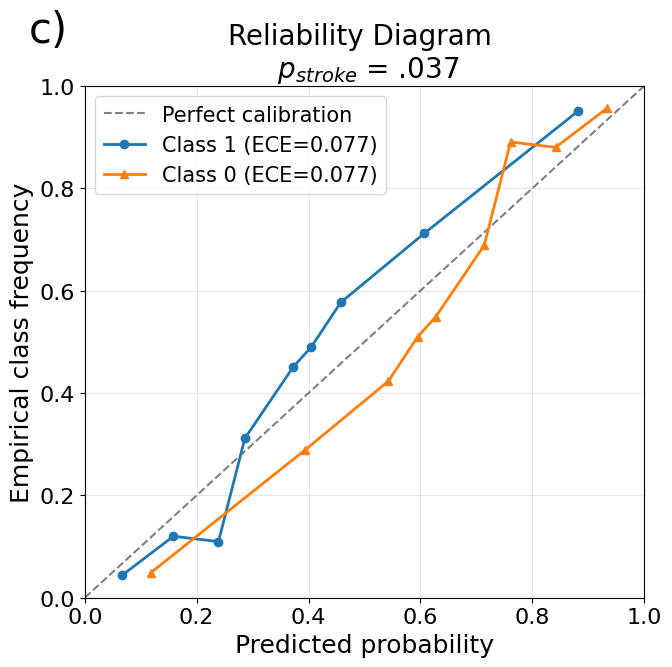

In [12]:
evaluate_venn_abers_both_classes(np.squeeze(intervals),test_gts)

{'global': {'prevalence_pos': 0.37699161084736943,
  'prevalence_neg': 0.6230083891526306},
 'sharpness': {'mean_width': 0.008113165210319323,
  'median_width': 0.005154669284820557,
  'p90_width': 0.014136552810668945,
  'max_width': 0.13694489002227783},
 'collapsed_metrics': {'brier_score': 0.4906110299244505,
  'log_loss': 1.5495332060398832,
  'ece_pos': 0.48206882786187943,
  'ece_neg': 0.4820688278618794},
 'reliability_table': [{'bin': 0,
   'count': 1729,
   'empirical_rate_pos': 0.3649508386350492,
   'empirical_rate_neg': 0.6350491613649508,
   'avg_collapsed_p_pos': 0.4621200597641367,
   'avg_collapsed_p_neg': 0.5378799402358633},
  {'bin': 1,
   'count': 2334,
   'empirical_rate_pos': 0.32390745501285345,
   'empirical_rate_neg': 0.6760925449871465,
   'avg_collapsed_p_pos': 0.7861391207576286,
   'avg_collapsed_p_neg': 0.21386087924237135},
  {'bin': 2,
   'count': 1598,
   'empirical_rate_pos': 0.3886107634543179,
   'empirical_rate_neg': 0.6113892365456821,
   'avg_col

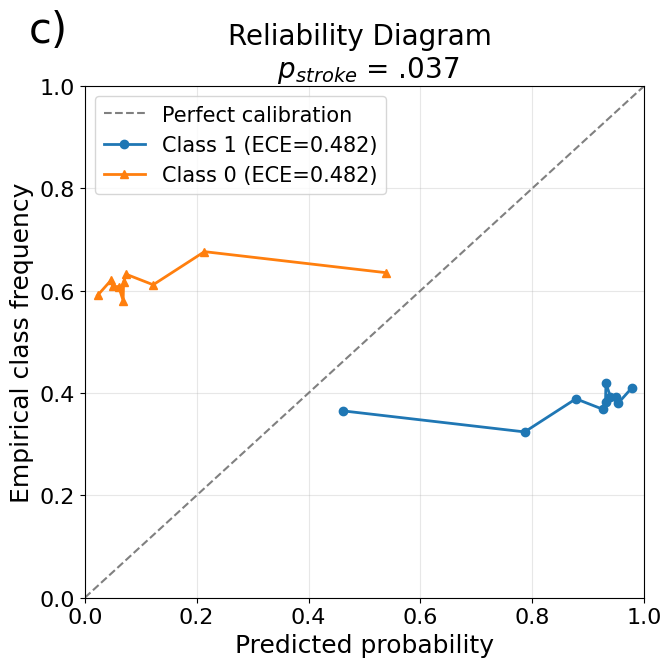

In [13]:
evaluate_venn_abers_both_classes(np.squeeze(intervals_noise),test_noise_gts)

# error composition

In [14]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)

def print_confusion_percentages(out, subset,tag):
    tp = out[subset]["tp"]
    fp = out[subset]["fp"]
    tn = out[subset]["tn"]
    fn = out[subset]["fn"]

    total = tp + fp + tn + fn

    print(f"\n{subset.upper()}")
    print(f"\n{tag.upper()}")
    print("-" * 30)
    print(f"Total: {total}")

    if total == 0:
        print("No examples in this subset.")
        return
    
    print(f"TP: {tp} ({100 * tp / total:.2f}%)")
    print(f"FP: {fp} ({100 * fp / total:.2f}%)")
    print(f"TN: {tn} ({100 * tn / total:.2f}%)")
    print(f"FN: {fn} ({100 * fn / total:.2f}%)")


print_confusion_percentages(out_mag_filtered, "overall",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "rejected",'Prob filter noisy')
print_confusion_percentages(out_mag_filtered, "retained",'Prob retained noisy')


OVERALL

PROB FILTER NOISY
------------------------------
Total: 15377
TP: 5374 (34.95%)
FP: 8892 (57.83%)
TN: 688 (4.47%)
FN: 423 (2.75%)

REJECTED

PROB FILTER NOISY
------------------------------
Total: 7689
TP: 2340 (30.43%)
FP: 4238 (55.12%)
TN: 688 (8.95%)
FN: 423 (5.50%)

RETAINED

PROB RETAINED NOISY
------------------------------
Total: 7688
TP: 3034 (39.46%)
FP: 4654 (60.54%)
TN: 0 (0.00%)
FN: 0 (0.00%)


In [15]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.037)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals_noise),
    y_true=test_noise_gts,
    cost_fn=cost_fn,
    threshold=0.5,
    reject_fraction=0.5,
    pred_method="collapse",
)



print_confusion_percentages(out_ec_filtered, "overall",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered noisy')
print_confusion_percentages(out_ec_filtered, "retained",'ec retained noisy')


OVERALL

EC FILTERED NOISY
------------------------------
Total: 15377
TP: 5374 (34.95%)
FP: 8892 (57.83%)
TN: 688 (4.47%)
FN: 423 (2.75%)

REJECTED

EC FILTERED NOISY
------------------------------
Total: 7689
TP: 2340 (30.43%)
FP: 4238 (55.12%)
TN: 688 (8.95%)
FN: 423 (5.50%)

RETAINED

EC RETAINED NOISY
------------------------------
Total: 7688
TP: 3034 (39.46%)
FP: 4654 (60.54%)
TN: 0 (0.00%)
FN: 0 (0.00%)


In [16]:
cost_fn = partial(compute_single_prediction_cost,p_stroke_missed_af=0.037)

out_ec_filtered = evaluate_va_expected_cost_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    cost_fn=cost_fn,
    threshold=0.5,
    reject_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_ec_filtered, "overall",'ec filtered clean')
print_confusion_percentages(out_ec_filtered, "rejected",'ec filtered clean')


OVERALL

EC FILTERED CLEAN
------------------------------
Total: 15377
TP: 2333 (15.17%)
FP: 409 (2.66%)
TN: 9171 (59.64%)
FN: 3464 (22.53%)

REJECTED

EC FILTERED CLEAN
------------------------------
Total: 7689
TP: 0 (0.00%)
FP: 0 (0.00%)
TN: 4675 (60.80%)
FN: 3014 (39.20%)


In [17]:
out_mag_filtered = evaluate_va_prob_magnitude_filtering(
    intervals=np.squeeze(intervals),
    y_true=test_gts,
    retain_fraction=0.5,
    pred_method="collapse",
)




print_confusion_percentages(out_mag_filtered, "overall",'prob filtered clean')
print_confusion_percentages(out_mag_filtered, "rejected",'prob filtered clean')


OVERALL

PROB FILTERED CLEAN
------------------------------
Total: 15377
TP: 2333 (15.17%)
FP: 409 (2.66%)
TN: 9171 (59.64%)
FN: 3464 (22.53%)

REJECTED

PROB FILTERED CLEAN
------------------------------
Total: 7689
TP: 1097 (14.27%)
FP: 368 (4.79%)
TN: 3408 (44.32%)
FN: 2816 (36.62%)
